# 02 - Prototyping (JAX)

## GoHREP

**Goal:**

Validate the full technical pipeline by prototyping a JAX/Flax classification head on top of frozen ESM-2 encoders, establish frozen embedding baselines for both the 150M and 650M ESM-2 variants using 5-fold cross validation, and characterise error patterns to inform LoRA fine-tuning strategy in notebook 03.

**Hypothesis:**

Frozen ESM-2 embeddings, without any fine-tuning, will capture sufficient sequence-level biochemical signal to produce above-chance classification of pathogen virulence genes into 8 functional classes. The 650M model will produce higher-quality embeddings than the 150M model due to its greater representational capacity, and the majority of misclassifications will occur at biologically ambiguous class boundaries identified during data curation rather than being distributed randomly.

**Rationale:**

Prototyping with frozen encoders and a lightweight trainable head is a low-cost way to validate the entire pipeline — data loading, tokenization, embedding extraction, gradient flow, and memory constraints — before investing compute in full LoRA fine-tuning. If frozen embeddings already produce meaningfully above-chance performance (random baseline ≈ 12.5% for 8 classes), this provides early evidence that ESM-2's pre-trained representations encode functional class information and that fine-tuning is likely to yield further gains. Comparing 150M and 650M at the frozen baseline stage is computationally cheap relative to fine-tuning both, and informs which model size to prioritise for LoRA. 5-fold cross validation on the training pool provides a more reliable performance estimate than a single fixed validation split, particularly important for the smaller classes (Protease: 199 sequences, Secretion system: 202 sequences). Any pipeline failures caught here are far cheaper to fix than failures discovered mid fine-tuning.

**Experimental Plan:**

1. **Data loading and tokenization:** Load the curated train and test CSV splits from `data/splits/`. Verify label mapping and class distributions. Implement and validate tokenization using the ESM-2 tokenizer, confirming correct handling of sequences up to 1,024 tokens and random cropping for longer sequences.
2. **Classification head implementation:** Define an 8-class JAX/Flax classification head on top of frozen ESM-2 embeddings using global mean pooling over residue tokens (excluding `<cls>` and `<eos>`), with progressive dimension reduction (640/1280 → 256 → 128 → 8) and dropout regularisation. Instantiate separately for 150M and 650M variants.
3. **Forward pass validation:** Confirm the pipeline produces output tensors of shape `(batch_size, 8)` for both model sizes and that random initialisation yields approximately uniform class predictions (expected loss ≈ −ln(1/8) ≈ 2.08).
4. **Gradient flow validation:** Compute gradients through the classification head for both model sizes and verify that all parameters receive non-zero gradients of healthy magnitude, confirming the pipeline is ready for training.
5. **Baseline evaluation with 5-fold cross validation:** Train the classification head on frozen embeddings from both ESM-2 variants using stratified 5-fold cross validation on the training pool, with class-weighted cross-entropy loss. Report mean ± std macro F1, per-class F1, and averaged confusion matrices

# 0 Environment Setup

This section mounts Google Drive and installs dependencies from the GitHub repository.

In [1]:
import yaml
from google.colab import drive
import os

drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

model_config_path = os.path.join(PROJECT_ROOT, "configs/model_config.yaml")
with open(model_config_path, 'r') as f:
    config = yaml.safe_load(f)

data_config_path = os.path.join(PROJECT_ROOT, "configs/data_config.yaml")
with open(data_config_path, 'r') as f:
    data_config = yaml.safe_load(f)

Mounted at /content/drive


In [2]:
if os.path.exists("requirements.txt"):
    !pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/72

In [3]:
import torch
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel

## 1 Data Loading and Tokenization

This section loads the curated train and test splits saved during data curation, verifies label integrity and class distributions, implements tokenization using the ESM-2 tokenizer, and validates correct handling of sequences up to 1,024 tokens before building the classification head.

In [4]:
# Load curated splits from data curation
splits_dir = os.path.join(PROJECT_ROOT, data_config['paths']['splits_dir'])

df_train = pd.read_csv(os.path.join(splits_dir, "train.csv"))
df_test  = pd.read_csv(os.path.join(splits_dir, "test.csv"))

print(f"Train pool: {len(df_train)} sequences")
print(f"Test:       {len(df_test)} sequences")

# Verify label mapping is consistent with config
label_mapping = data_config['target_mapping']
print(f"\nLabel mapping: {label_mapping}")

# Verify all functional classes in splits are present in config mapping
train_classes = set(df_train['functional_class'].unique())
test_classes  = set(df_test['functional_class'].unique())
missing = (train_classes | test_classes) - set(label_mapping.keys())
assert not missing, f"Classes in splits missing from config mapping: {missing}"
print("All classes present in config label mapping: OK")

Train pool: 4023 sequences
Test:       447 sequences

Label mapping: {'Effector': 0, 'Transcription factor / Regulator': 1, 'Kinase / Signalling': 2, 'Protease': 3, 'Cell wall / Carbohydrate-active': 4, 'Transporter / Membrane': 5, 'Secondary metabolite / Biosynthesis': 6, 'Secretion system': 7}
All classes present in config label mapping: OK


In [5]:
# Verify class distributions across splits
total = len(df_train) + len(df_test)

print("Class distributions:")
print(f"\n{'Class':<45} {'Train':>8} {'Test':>8} {'Total':>8} {'%':>7}")
print("-" * 80)
for cls in sorted(label_mapping.keys(), key=lambda x: label_mapping[x]):
    train_count = (df_train['functional_class'] == cls).sum()
    test_count  = (df_test['functional_class'] == cls).sum()
    class_total = train_count + test_count
    pct = class_total / total * 100
    print(f"{cls:<45} {train_count:>8} {test_count:>8} {class_total:>8} {pct:>6.1f}%")
print("-" * 80)
print(f"{'Total':<45} {len(df_train):>8} {len(df_test):>8} {total:>8} {'100.0%':>7}")

Class distributions:

Class                                            Train     Test    Total       %
--------------------------------------------------------------------------------
Effector                                           588       65      653   14.6%
Transcription factor / Regulator                  1383      154     1537   34.4%
Kinase / Signalling                                888       99      987   22.1%
Protease                                           179       20      199    4.5%
Cell wall / Carbohydrate-active                    248       27      275    6.2%
Transporter / Membrane                             330       37      367    8.2%
Secondary metabolite / Biosynthesis                225       25      250    5.6%
Secretion system                                   182       20      202    4.5%
--------------------------------------------------------------------------------
Total                                             4023      447     4470  100.0%


In [6]:
# Validate tokenization on a small representative batch
model_name = config['model']['models']['small']
tokenizer = AutoTokenizer.from_pretrained(model_name)
MAX_LEN = config['memory']['max_token_length']

# Sample sequences spanning the length distribution
sample_df = df_train.sample(8, random_state=42)
sample_seqs    = sample_df['sequence'].tolist()
sample_labels  = sample_df['label'].tolist()
sample_classes = sample_df['functional_class'].tolist()

tokens = tokenizer(
    sample_seqs,
    padding=True,
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt"
)

print(f"Tokenization test batch:")
print(f"  Input IDs shape:      {tokens['input_ids'].shape}")
print(f"  Attention mask shape: {tokens['attention_mask'].shape}")
print(f"  Sequence lengths:     {tokens['attention_mask'].sum(dim=1).tolist()}")
print(f"  Labels:               {sample_labels}")
print(f"  Classes:              {sample_classes}")

# Flag sequences exceeding ESM-2 context window (1,024 tokens = 1,022 residues + CLS + EOS)
all_seqs = df_train['sequence'].tolist() + df_test['sequence'].tolist()
truncated = sum(1 for s in all_seqs if len(s) > MAX_LEN - 2)
print(f"\nSequences exceeding {MAX_LEN - 2} aa (will use random cropping): {truncated} / {len(all_seqs)} ({truncated/len(all_seqs)*100:.1f}%)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenization test batch:
  Input IDs shape:      torch.Size([8, 900])
  Attention mask shape: torch.Size([8, 900])
  Sequence lengths:     [396, 328, 484, 507, 101, 186, 328, 900]
  Labels:               [1, 4, 3, 1, 0, 1, 0, 3]
  Classes:              ['Transcription factor / Regulator', 'Cell wall / Carbohydrate-active', 'Protease', 'Transcription factor / Regulator', 'Effector', 'Transcription factor / Regulator', 'Effector', 'Protease']

Sequences exceeding 1022 aa (will use random cropping): 233 / 4470 (5.2%)


## 2 Classification Head Implementation

This section defines a JAX/Flax classification head on top of the frozen ESM-2 encoder. Global average pooling is used rather than the CLS token to aggregate sequence-level information, which is more appropriate for multi-domain virulence proteins where functional signal is distributed across the full sequence rather than concentrated at a single position.

The attention mask handling is an important addition over the original NLR notebook - without masking, padding tokens contribute to the mean pooling and dilute the signal from real residues, which is particularly problematic for shorter sequences padded to the full 1,024 token length.

In [7]:
import flax.linen as nn
import jax.numpy as jnp

class VirulenceClassifier(nn.Module):
    num_classes: int = 8
    hidden_dim: int = 640     # set to 640 for 150M, 1280 for 650M
    layer_1_dim: int = 256
    layer_2_dim: int = 128
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, esm_embeddings, attention_mask=None, training=False):
        # esm_embeddings shape: (batch_size, seq_len, hidden_dim)

        # Global mean pooling over residue tokens, masking padding
        if attention_mask is not None:
            mask = attention_mask[:, :, None]  # (batch_size, seq_len, 1)
            sum_embeddings = (esm_embeddings * mask).sum(axis=1)
            lengths = mask.sum(axis=1)
            pooled = sum_embeddings / lengths  # (batch_size, hidden_dim)
        else:
            pooled = jnp.mean(esm_embeddings, axis=1)

        # Classification head with progressive dimension reduction
        x = nn.Dense(self.layer_1_dim)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)

        x = nn.Dense(self.layer_2_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)

        logits = nn.Dense(self.num_classes)(x)
        return logits


# Instantiate classifiers for both model sizes
classifiers = {}
for size in config['model']['models']:
    hidden_dim = config['model']['hidden_dims'][size]
    model_name = config['model']['models'][size]
    classifiers[size] = VirulenceClassifier(
        num_classes=config['model']['num_classes'],
        hidden_dim=hidden_dim,
        layer_1_dim=config['classification_head']['layer_1_dim'],
        layer_2_dim=config['classification_head']['layer_2_dim'],
        dropout_rate=config['model']['dropout_rate']
    )
    print(f"VirulenceClassifier ({size} — {model_name}):")
    print(f"  Input:    (batch_size, seq_len, {hidden_dim})")
    print(f"  Pooled:   (batch_size, {hidden_dim})")
    print(f"  Layer 1:  (batch_size, {config['classification_head']['layer_1_dim']})")
    print(f"  Layer 2:  (batch_size, {config['classification_head']['layer_2_dim']})")
    print(f"  Output:   (batch_size, {config['model']['num_classes']})\n")

VirulenceClassifier (small — facebook/esm2_t30_150M_UR50D):
  Input:    (batch_size, seq_len, 640)
  Pooled:   (batch_size, 640)
  Layer 1:  (batch_size, 256)
  Layer 2:  (batch_size, 128)
  Output:   (batch_size, 8)

VirulenceClassifier (large — facebook/esm2_t33_650M_UR50D):
  Input:    (batch_size, seq_len, 1280)
  Pooled:   (batch_size, 1280)
  Layer 1:  (batch_size, 256)
  Layer 2:  (batch_size, 128)
  Output:   (batch_size, 8)



## 3 Forward Pass Validation

This section tests that the full pipeline — ESM-2 embedding extraction followed by classification head inference — produces correctly shaped outputs and that random initialisation yields approximately uniform predictions across all 8 classes. The expected loss at random initialisation is −ln(1/8) ≈ 2.08. Both the 150M and 650M ESM-2 variants are validated here before committing to full baseline training.

The attention mask is passed through to the classifier to ensure padding tokens are excluded from mean pooling. A large deviation from −ln(1/8) at random initialisation would indicate a problem with the initialisation or label mapping.

In [8]:
# Load both ESM-2 encoders (frozen)
esm_models = {}
for size, model_name in config['model']['models'].items():
    esm_models[size] = AutoModel.from_pretrained(model_name).eval().to("cuda")
    n_params = sum(p.numel() for p in esm_models[size].parameters())
    print(f"Loaded {size} ({model_name})")
    print(f"  Parameters: {n_params:,}")
    print(f"  Device:     {next(esm_models[size].parameters()).device}\n")

model.safetensors:   0%|          | 0.00/595M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded small (facebook/esm2_t30_150M_UR50D)
  Parameters: 148,138,841
  Device:     cuda:0



config.json:   0%|          | 0.00/724 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded large (facebook/esm2_t33_650M_UR50D)
  Parameters: 651,040,661
  Device:     cuda:0



In [9]:
# Extract frozen ESM-2 embeddings for the test batch and validate shapes
embeddings_by_size = {}
for size, esm_model in esm_models.items():
    with torch.no_grad():
        inputs = {k: v.to("cuda") for k, v in tokens.items()}
        esm_outputs = esm_model(**inputs)
        embeddings = esm_outputs.last_hidden_state  # (batch_size, seq_len, hidden_dim)

    expected_dim = config['model']['hidden_dims'][size]
    print(f"ESM-2 {size} embedding shape: {embeddings.shape}")
    assert embeddings.shape[-1] == expected_dim, \
        f"Embedding dim mismatch for {size}: got {embeddings.shape[-1]}, expected {expected_dim}"
    print(f"  Embedding dim: OK ({expected_dim})\n")

    # Convert to JAX arrays
    embeddings_by_size[size] = (
        jnp.array(embeddings.cpu().numpy()),
        jnp.array(tokens['attention_mask'].numpy())
    )

ESM-2 small embedding shape: torch.Size([8, 900, 640])
  Embedding dim: OK (640)

ESM-2 large embedding shape: torch.Size([8, 900, 1280])
  Embedding dim: OK (1280)



In [10]:
# Initialise classifiers and run forward pass for both model sizes
idx_to_class = {v: k for k, v in data_config['target_mapping'].items()}
params_by_size = {}
key = jax.random.PRNGKey(42)

for size, classifier in classifiers.items():
    jax_embeddings, jax_mask = embeddings_by_size[size]

    # Initialise parameters
    params = classifier.init(key, jax_embeddings[:1], jax_mask[:1])
    params_by_size[size] = params
    param_count = sum(x.size for x in jax.tree_util.tree_leaves(params))
    print(f"Classification head ({size}) parameters: {param_count:,}")

    # Forward pass
    logits = classifier.apply(params, jax_embeddings, jax_mask)
    assert logits.shape == (len(sample_seqs), config['model']['num_classes']), \
        f"Output shape mismatch for {size}: got {logits.shape}"
    print(f"Output shape: {logits.shape} — OK")

    # Verify approximately uniform predictions at random initialisation
    probs = jax.nn.softmax(logits, axis=-1)
    predicted_classes = jnp.argmax(logits, axis=-1)

    print(f"\nRandom initialisation predictions ({size}):")
    print(f"{'Seq':<6} {'Predicted class':<45} {'Max prob':<12} {'True class'}")
    print("-" * 95)
    for i in range(len(sample_seqs)):
        pred_cls  = idx_to_class[int(predicted_classes[i])]
        true_cls  = sample_classes[i]
        print(f"{i:<6} {pred_cls:<45} {float(probs[i].max()):.4f}      {true_cls}")

    # Check initial loss against random baseline
    labels_jax = jnp.array(sample_labels)
    initial_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels_jax).mean()
    expected_random_loss = -jnp.log(1.0 / config['model']['num_classes'])

    print(f"\nInitial loss:         {float(initial_loss):.4f}")
    print(f"Expected random loss: {float(expected_random_loss):.4f}  (-ln(1/8))")
    print(f"Difference:           {abs(float(initial_loss) - float(expected_random_loss)):.4f}")
    print(f"Forward pass validation ({size}): OK\n")

Classification head (small) parameters: 198,024
Output shape: (8, 8) — OK

Random initialisation predictions (small):
Seq    Predicted class                               Max prob     True class
-----------------------------------------------------------------------------------------------
0      Effector                                      0.1506      Transcription factor / Regulator
1      Effector                                      0.1541      Cell wall / Carbohydrate-active
2      Effector                                      0.1504      Protease
3      Effector                                      0.1578      Transcription factor / Regulator
4      Effector                                      0.1552      Effector
5      Effector                                      0.1552      Transcription factor / Regulator
6      Effector                                      0.1601      Effector
7      Effector                                      0.1534      Protease

Initial loss:        

## 4 Gradient Flow Validation

This section verifies that gradients flow correctly through the classification head during backpropagation for both ESM-2 model sizes. All parameters should receive non-zero gradients with magnitudes in the range 1e-4 to 1e-1 — values below 1e-6 suggest vanishing gradients, while values above 1 suggest potential instability. A single optimiser step at the end confirms the full training loop works end to end and that the loss decreases in the correct direction, ruling out sign errors or learning rate issues before committing to full baseline training.

In [11]:
# Define loss function — takes classifier as argument to support both model sizes
def cross_entropy_loss(params, classifier, embeddings, mask, labels, training=False):
    logits = classifier.apply(params, embeddings, mask, training=training)
    return optax.softmax_cross_entropy_with_integer_labels(logits, labels).mean()

expected_random_loss = -jnp.log(1.0 / config['model']['num_classes'])
labels_jax = jnp.array(sample_labels)

for size, classifier in classifiers.items():
    print(f"{'='*60}")
    print(f"Gradient flow validation — {size}")
    print(f"{'='*60}\n")

    jax_embeddings, jax_mask = embeddings_by_size[size]
    params = params_by_size[size]

    # Compute loss and gradients
    loss_and_grad_fn = jax.value_and_grad(cross_entropy_loss)
    loss_val, grads = loss_and_grad_fn(
        params, classifier, jax_embeddings, jax_mask, labels_jax
    )

    print(f"Loss at random initialisation: {float(loss_val):.4f}")
    print(f"Expected random baseline:      {float(expected_random_loss):.4f}\n")

    # Inspect gradient shapes and magnitudes
    print(f"{'Parameter':<45} {'Shape':<25} {'Mean |grad|':<15} {'Status'}")
    print("-" * 100)

    all_healthy = True
    for layer, layer_grads in jax.tree_util.tree_leaves_with_path(grads):
        path = ".".join([str(p.key) for p in layer[:-1]])
        mean_abs = float(jnp.mean(jnp.abs(layer_grads)))
        shape = layer_grads.shape

        if mean_abs < 1e-6:
            status = "⚠ VANISHING"
            all_healthy = False
        elif mean_abs > 1.0:
            status = "⚠ EXPLODING"
            all_healthy = False
        else:
            status = "✓ OK"

        print(f"{path:<45} {str(shape):<25} {mean_abs:<15.6f} {status}")

    print(f"\nAll gradients healthy: {'✓ YES' if all_healthy else '✗ NO — investigate flagged layers'}")

    # Check for zero gradients
    zero_grad_params = [
        ".".join([str(p.key) for p in path])
        for path, grad in jax.tree_util.tree_leaves_with_path(grads)
        if jnp.all(grad == 0)
    ]
    if zero_grad_params:
        print(f"⚠ Parameters with zero gradients:")
        for p in zero_grad_params:
            print(f"  {p}")
    else:
        print("✓ No zero-gradient parameters detected")

    # Single test optimiser step
    optimiser = optax.adam(learning_rate=config['training']['learning_rate'])
    opt_state = optimiser.init(params)
    updates, _ = optimiser.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)

    new_loss = cross_entropy_loss(new_params, classifier, jax_embeddings, jax_mask, labels_jax)
    print(f"\nLoss before update: {float(loss_val):.4f}")
    print(f"Loss after update:  {float(new_loss):.4f}")
    print(f"Loss decreased:     {'✓ YES' if new_loss < loss_val else '✗ NO — check learning rate and gradient signs'}\n")

Gradient flow validation — small

Loss at random initialisation: 2.1063
Expected random baseline:      2.0794

Parameter                                     Shape                     Mean |grad|     Status
----------------------------------------------------------------------------------------------------
params.Dense_0                                (256,)                    0.007206        ✓ OK
params.Dense_0                                (640, 256)                0.000578        ✓ OK
params.Dense_1                                (128,)                    0.014374        ✓ OK
params.Dense_1                                (256, 128)                0.001590        ✓ OK
params.Dense_2                                (8,)                      0.126535        ✓ OK
params.Dense_2                                (128, 8)                  0.008868        ✓ OK

All gradients healthy: ✓ YES
✓ No zero-gradient parameters detected

Loss before update: 2.1063
Loss after update:  2.0906
Loss decrea

## 5 Baseline Performance

This section trains the classification head on frozen ESM-2 embeddings using 5-fold cross validation, establishing whether ESM-2's pre-trained representations encode sufficient functional class signal without any encoder fine-tuning. Both the 150M and 650M ESM-2 variants are evaluated. This serves as the lower bound reference for the LoRA fine-tuned model.

- **Random chance:** 12.5% (8 classes)
- **Frozen embeddings + trained head (150M):** measured here
- **Frozen embeddings + trained head (650M):** measured here
- **LoRA fine-tuned:** measured in notebook 03

In [12]:
# Pre-extract frozen embeddings for the full training pool — once per model size
from torch.utils.data import DataLoader, TensorDataset

def extract_embeddings(sequences, tokenizer, esm_model, batch_size=8, max_len=1024):
    """Extract frozen ESM-2 embeddings for a list of sequences."""
    all_embeddings = []
    all_masks = []

    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i:i + batch_size]
        tokens = tokenizer(
            batch_seqs,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )
        with torch.no_grad():
            inputs = {k: v.to("cuda") for k, v in tokens.items()}
            outputs = esm_model(**inputs)
            embeddings = outputs.last_hidden_state.cpu().numpy()
            masks = tokens['attention_mask'].cpu().numpy()

        # Pad to max_len for consistent array shapes
        pad_len = max_len - embeddings.shape[1]
        if pad_len > 0:
            embeddings = np.pad(embeddings, ((0,0),(0,pad_len),(0,0)))
            masks = np.pad(masks, ((0,0),(0,pad_len)))

        all_embeddings.append(embeddings)
        all_masks.append(masks)

    return np.concatenate(all_embeddings, axis=0), np.concatenate(all_masks, axis=0)


train_sequences = df_train['sequence'].tolist()
train_labels_np = df_train['label'].values
batch_size = config['training']['batch_size']

embeddings_by_size = {}
for size, esm_model in esm_models.items():
    print(f"Extracting frozen embeddings — {size}...")
    embs, masks = extract_embeddings(
        train_sequences, tokenizer, esm_model,
        batch_size=batch_size,
        max_len=config['memory']['max_token_length']
    )
    embeddings_by_size[size] = (embs, masks)
    print(f"  Embeddings shape: {embs.shape}")
    print(f"  Masks shape:      {masks.shape}\n")

Extracting frozen embeddings — small...
  Embeddings shape: (4023, 1024, 640)
  Masks shape:      (4023, 1024)

Extracting frozen embeddings — large...
  Embeddings shape: (4023, 1024, 1280)
  Masks shape:      (4023, 1024)



In [13]:
# Compute class weights inversely proportional to frequency
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(config['model']['num_classes']),
    y=train_labels_np
)
class_weights_jax = jnp.array(class_weights, dtype=jnp.float32)

print("Class weights:")
for cls, idx in sorted(data_config['target_mapping'].items(), key=lambda x: x[1]):
    print(f"  {cls:<45} {class_weights[idx]:.3f}")

Class weights:
  Effector                                      0.855
  Transcription factor / Regulator              0.364
  Kinase / Signalling                           0.566
  Protease                                      2.809
  Cell wall / Carbohydrate-active               2.028
  Transporter / Membrane                        1.524
  Secondary metabolite / Biosynthesis           2.235
  Secretion system                              2.763


In [14]:
# Define JIT-compiled train and eval step functions
def make_train_step(classifier, optimiser, class_weights_jax):
    @jax.jit
    def train_step(params, opt_state, embeddings, mask, labels, dropout_key):
        def loss_fn(params):
            logits = classifier.apply(
                params, embeddings, mask,
                training=True,
                rngs={'dropout': dropout_key}
            )
            per_sample_loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
            sample_weights = class_weights_jax[labels]
            return (per_sample_loss * sample_weights).mean()
        loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, new_opt_state = optimiser.update(grads, opt_state)
        new_params = optax.apply_updates(params, updates)
        return new_params, new_opt_state, loss
    return train_step

def make_eval_step(classifier):
    @jax.jit
    def eval_step(params, embeddings, mask):
        return classifier.apply(params, embeddings, mask, training=False)
    return eval_step

In [15]:
# 5-fold cross validation for both model sizes
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pickle
import os

k_folds = config['training']['k_folds']
n_epochs = config['training']['max_epochs']
patience = config['training']['early_stopping_patience']
idx_to_class = {v: k for k, v in data_config['target_mapping'].items()}
class_names = [idx_to_class[i] for i in range(config['model']['num_classes'])]

skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
checkpoint_dir = os.path.join(PROJECT_ROOT, config['paths']['checkpoint_dir'])
meta_path = os.path.join(checkpoint_dir, "baseline_results.pkl")

results = {}
train_steps = {}
eval_steps = {}

sizes_trained = []

for size, classifier in classifiers.items():
    eval_steps[size] = make_eval_step(classifier)

    # Check if all fold checkpoints exist for this model size
    fold_paths = [
        os.path.join(checkpoint_dir, f"baseline_{size}_fold{fold}.pkl")
        for fold in range(k_folds)
    ]
    all_checkpoints_exist = all(os.path.exists(p) for p in fold_paths)

    if all_checkpoints_exist and os.path.exists(meta_path):
        print(f"Checkpoints found for {size} — loading from disk...\n")

        with open(meta_path, 'rb') as f:
            saved_meta = pickle.load(f)
        results[size] = saved_meta[size]
        results[size]['best_params'] = {}

        for fold, path in enumerate(fold_paths):
            with open(path, 'rb') as f:
                results[size]['best_params'][fold] = pickle.load(f)
            print(f"  Loaded fold {fold+1}: {path}")

        print(f"\n{size} baseline (loaded) — macro F1: {results[size]['mean_f1']:.4f} ± {results[size]['std_f1']:.4f}  |  Accuracy: {results[size]['mean_acc']*100:.1f}% ± {results[size]['std_acc']*100:.1f}%\n")

    else:
        print(f"\n{'='*65}")
        print(f"No checkpoints found for {size} — training from scratch")
        print(f"({config['model']['models'][size]})")
        print(f"{'='*65}\n")

        embs_np, masks_np = embeddings_by_size[size]
        optimiser = optax.adam(learning_rate=config['training']['learning_rate'])
        train_steps[size] = make_train_step(classifier, optimiser, class_weights_jax)

        results[size] = {
            'fold_f1s': [],
            'fold_reports': [],
            'fold_accs': [],
            'best_params': {}
        }

        for fold, (train_idx, val_idx) in enumerate(skf.split(embs_np, train_labels_np)):
            print(f"Fold {fold+1}/{k_folds}  |  Train: {len(train_idx)}  Val: {len(val_idx)}")

            fold_embs_train   = embs_np[train_idx]
            fold_masks_train  = masks_np[train_idx]
            fold_labels_train = train_labels_np[train_idx]
            fold_embs_val     = embs_np[val_idx]
            fold_masks_val    = masks_np[val_idx]
            fold_labels_val   = train_labels_np[val_idx]

            key = jax.random.PRNGKey(fold)
            params = classifier.init(key, jnp.array(fold_embs_train[:1]), jnp.array(fold_masks_train[:1]))
            opt_state = optimiser.init(params)

            best_val_f1 = 0
            best_params = params
            patience_counter = 0

            for epoch in range(n_epochs):
                perm = np.random.permutation(len(fold_labels_train))
                epoch_losses = []

                for i in range(0, len(fold_labels_train), batch_size):
                    key, dropout_key = jax.random.split(key)
                    idx = perm[i:i + batch_size]
                    params, opt_state, loss = train_steps[size](
                        params, opt_state,
                        jnp.array(fold_embs_train[idx]),
                        jnp.array(fold_masks_train[idx]),
                        jnp.array(fold_labels_train[idx]),
                        dropout_key
                    )
                    epoch_losses.append(float(loss))

                val_logits = np.concatenate([
                    np.array(eval_steps[size](
                        params,
                        jnp.array(fold_embs_val[i:i+batch_size]),
                        jnp.array(fold_masks_val[i:i+batch_size])
                    ))
                    for i in range(0, len(fold_labels_val), batch_size)
                ], axis=0)

                val_preds = np.argmax(val_logits, axis=1)
                val_f1 = f1_score(fold_labels_val, val_preds, average='macro')
                val_acc = (val_preds == fold_labels_val).mean()

                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_params = params
                    patience_counter = 0
                    improved = "✓"
                else:
                    patience_counter += 1
                    improved = f"(no improvement {patience_counter}/{patience})"

                print(f"  Epoch {epoch+1:>2}/{n_epochs}  |  Loss: {np.mean(epoch_losses):.4f}  |  Val macro F1: {val_f1:.4f}  |  Val acc: {val_acc*100:.1f}%  {improved}")

                if patience_counter >= patience:
                    print(f"  Early stopping at epoch {epoch+1}\n")
                    break

            final_logits = np.concatenate([
                np.array(eval_steps[size](
                    best_params,
                    jnp.array(fold_embs_val[i:i+batch_size]),
                    jnp.array(fold_masks_val[i:i+batch_size])
                ))
                for i in range(0, len(fold_labels_val), batch_size)
            ], axis=0)

            final_preds = np.argmax(final_logits, axis=1)
            fold_f1 = f1_score(fold_labels_val, final_preds, average='macro')
            fold_acc = (final_preds == fold_labels_val).mean()

            results[size]['fold_f1s'].append(fold_f1)
            results[size]['fold_accs'].append(fold_acc)
            results[size]['fold_reports'].append(
                classification_report(fold_labels_val, final_preds, target_names=class_names, digits=3, output_dict=True)
            )
            results[size]['best_params'][fold] = best_params

            print(f"Fold {fold+1} macro F1: {fold_f1:.4f}  |  Accuracy: {fold_acc*100:.1f}%\n")

        results[size]['mean_f1'] = np.mean(results[size]['fold_f1s'])
        results[size]['std_f1'] = np.std(results[size]['fold_f1s'])
        results[size]['mean_acc'] = np.mean(results[size]['fold_accs'])
        results[size]['std_acc'] = np.std(results[size]['fold_accs'])

        print(f"\n{size} baseline — macro F1: {results[size]['mean_f1']:.4f} ± {results[size]['std_f1']:.4f}  |  Accuracy: {results[size]['mean_acc']*100:.1f}% ± {results[size]['std_acc']*100:.1f}%")

        # Save checkpoints
        os.makedirs(checkpoint_dir, exist_ok=True)
        for fold, params in results[size]['best_params'].items():
            save_path = os.path.join(checkpoint_dir, f"baseline_{size}_fold{fold}.pkl")
            with open(save_path, 'wb') as f:
                pickle.dump(params, f)
            print(f"Saved: {save_path}")

        sizes_trained.append(size)

# Save results metadata only if any training occurred
if sizes_trained:
    results_meta = {
        size: {k: v for k, v in res.items() if k != 'best_params'}
        for size, res in results.items()
    }
    with open(meta_path, 'wb') as f:
        pickle.dump(results_meta, f)
    print(f"\nSaved results metadata: {meta_path}")
else:
    print("\nAll models loaded from checkpoints — metadata unchanged.")

Checkpoints found for small — loading from disk...

  Loaded fold 1: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold0.pkl
  Loaded fold 2: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold1.pkl
  Loaded fold 3: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold2.pkl
  Loaded fold 4: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold3.pkl
  Loaded fold 5: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold4.pkl

small baseline (loaded) — macro F1: 0.6979 ± 0.0185  |  Accuracy: 74.2% ± 0.8%

Checkpoints found for large — loading from disk...

  Loaded fold 1: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_large_fold0.pkl
  Loaded fold 2: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_large_fold1.pkl
  Loaded fold 3: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_large_fold2.pkl
  Loaded fold 4: /conte

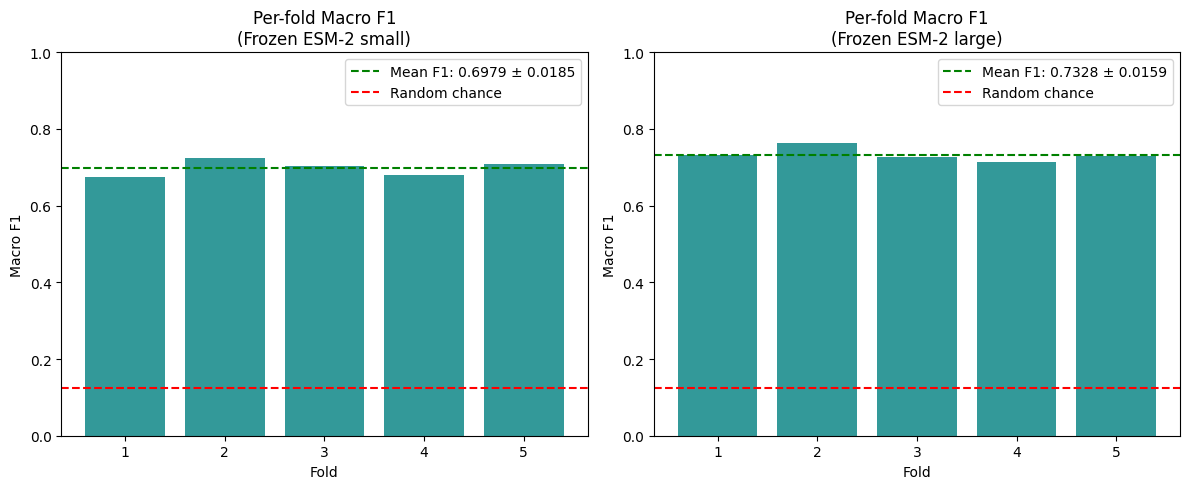

In [16]:
# Plot macro F1 across folds for both model sizes
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (size, res) in zip(axes, results.items()):
    folds = range(1, k_folds + 1)
    ax.bar(folds, res['fold_f1s'], color='teal', alpha=0.8)
    ax.axhline(y=res['mean_f1'], color='green', linestyle='--',
               label=f"Mean F1: {res['mean_f1']:.4f} ± {res['std_f1']:.4f}")
    ax.axhline(y=0.125, color='red', linestyle='--', label='Random chance')
    ax.set_title(f'Per-fold Macro F1\n(Frozen ESM-2 {size})')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Macro F1')
    ax.set_xticks(list(folds))
    ax.set_ylim(0, 1)
    ax.legend()

plt.tight_layout()
plt.show()

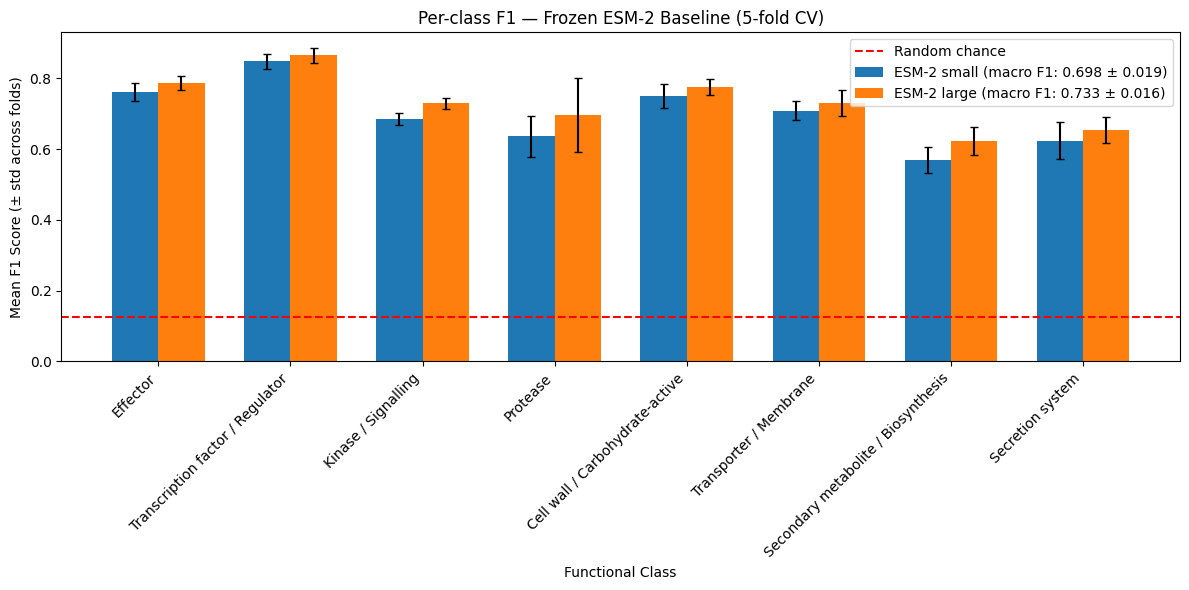

In [17]:
# Per-class F1 comparison across model sizes
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_names))
width = 0.35

for i, (size, res) in enumerate(results.items()):
    mean_cls_f1s = [
        np.mean([r[cls]['f1-score'] for r in res['fold_reports']])
        for cls in class_names
    ]
    std_cls_f1s = [
        np.std([r[cls]['f1-score'] for r in res['fold_reports']])
        for cls in class_names
    ]
    ax.bar(x + i * width, mean_cls_f1s, width,
           yerr=std_cls_f1s, capsize=3,
           label=f"ESM-2 {size} (macro F1: {res['mean_f1']:.3f} ± {res['std_f1']:.3f})")

ax.axhline(y=0.125, color='red', linestyle='--', label='Random chance')
ax.set_title('Per-class F1 — Frozen ESM-2 Baseline (5-fold CV)')
ax.set_xlabel('Functional Class')
ax.set_ylabel('Mean F1 Score (± std across folds)')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

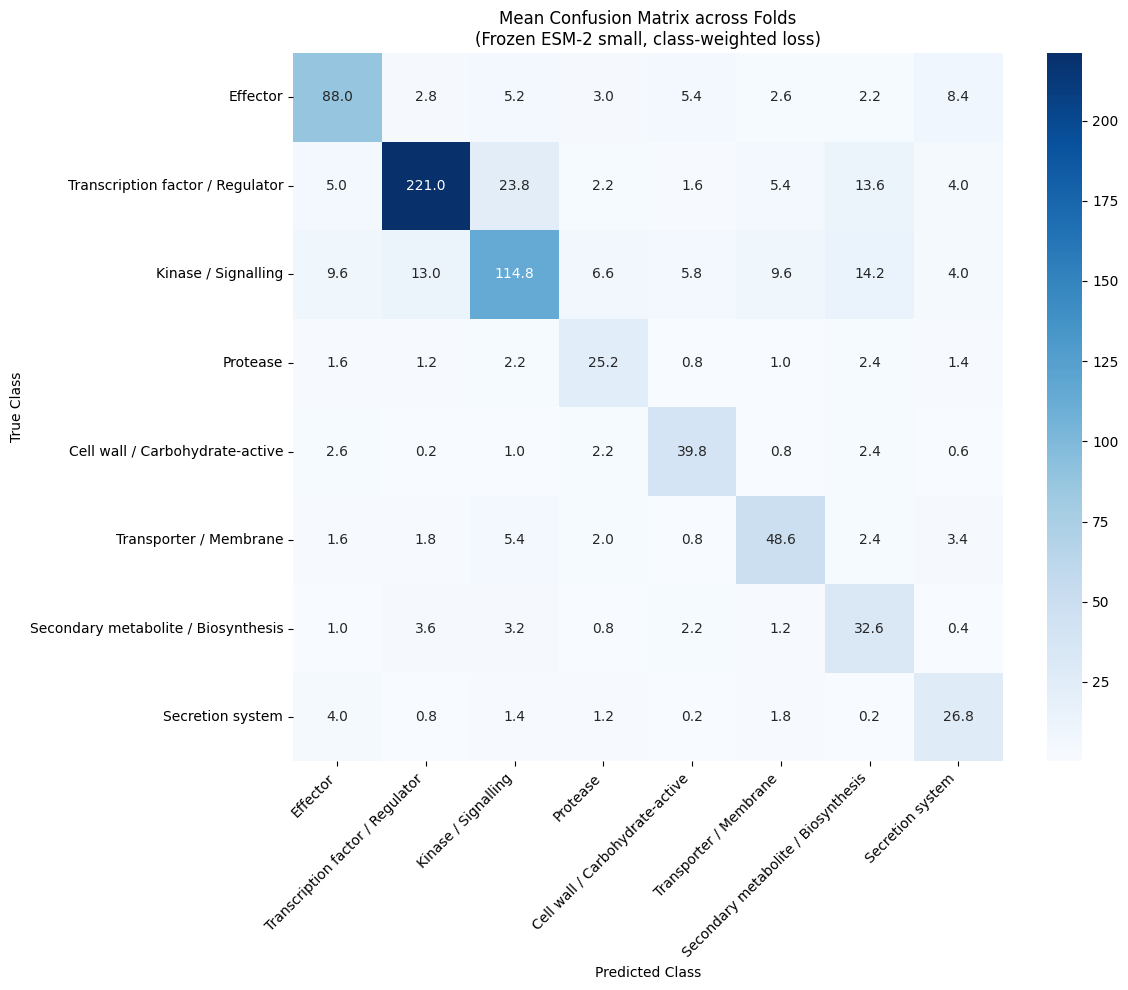

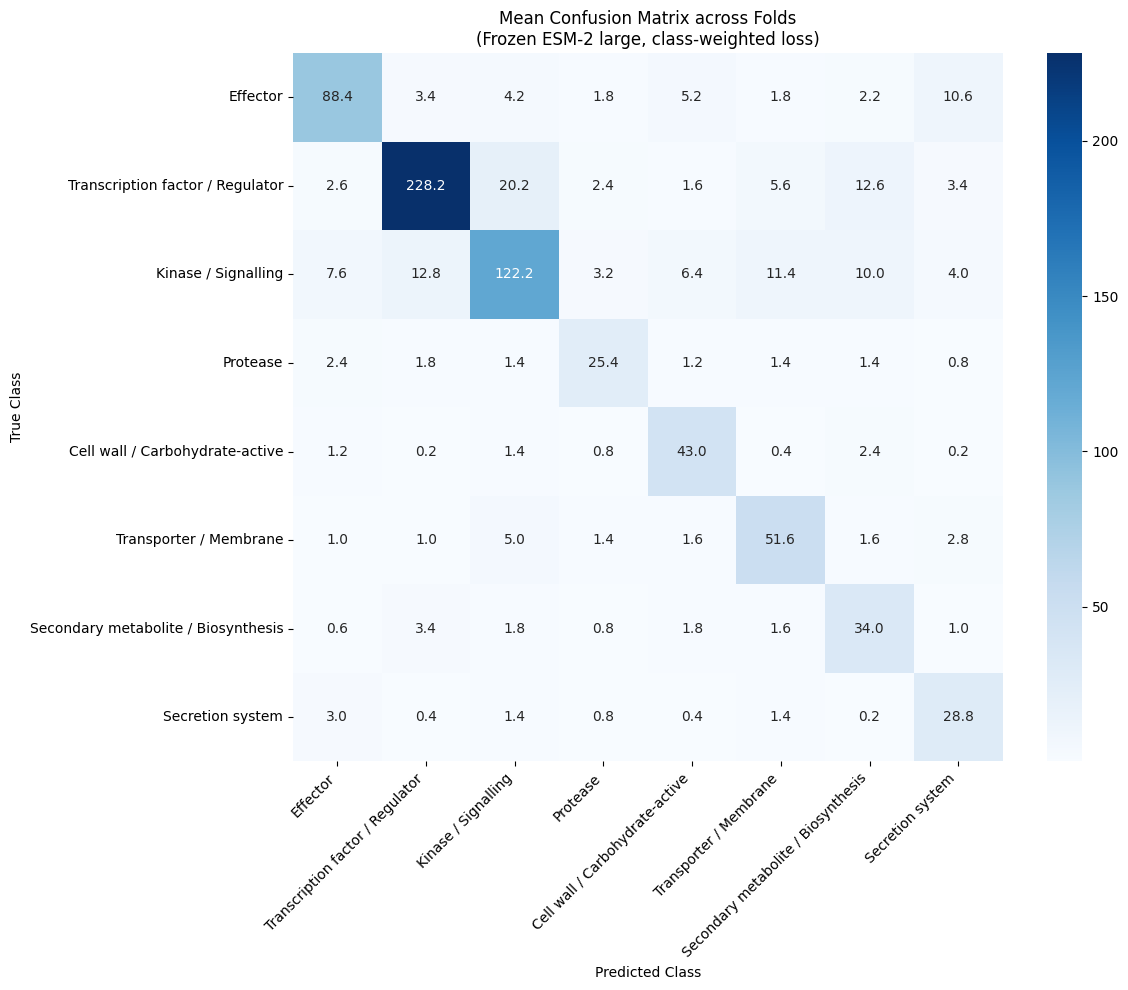

In [18]:
# Averaged confusion matrix across folds for each model size
for size, res in results.items():
    cms = np.array([
        confusion_matrix(
            train_labels_np[val_idx],
            np.argmax(np.concatenate([
                np.array(eval_steps[size](
                    res['best_params'][fold],
                    jnp.array(embeddings_by_size[size][0][val_idx][i:i+batch_size]),
                    jnp.array(embeddings_by_size[size][1][val_idx][i:i+batch_size])
                ))
                for i in range(0, len(val_idx), batch_size)
            ], axis=0), axis=1)
        )
        for fold, (_, val_idx) in enumerate(skf.split(
            embeddings_by_size[size][0], train_labels_np
        ))
    ])
    cm_mean = cms.mean(axis=0)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(
        cm_mean,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(f'Mean Confusion Matrix across Folds\n(Frozen ESM-2 {size}, class-weighted loss)')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 6 Error Analysis

This section analyses the sources of misclassification in the frozen ESM-2 baseline. We examine whether truncated sequences are disproportionately misclassified, inspect top-2 prediction confidence, and visualise the intermediate representations learned by the classification head using PCA. Analysis is performed on the best-performing fold for each model size.

In [19]:
# Select best fold per model size for error analysis
best_folds = {
    size: int(np.argmax(res['fold_f1s']))
    for size, res in results.items()
}
print("Best fold per model size:")
for size, fold in best_folds.items():
    print(f"  {size}: fold {fold+1} (macro F1: {results[size]['fold_f1s'][fold]:.4f})")

Best fold per model size:
  small: fold 2 (macro F1: 0.7234)
  large: fold 2 (macro F1: 0.7621)


In [20]:
# Re-extract predictions for the best fold per model size
MAX_LEN = config['memory']['max_token_length']
error_analysis = {}

for size, res in results.items():
    best_fold = best_folds[size]
    _, val_idx = list(skf.split(embeddings_by_size[size][0], train_labels_np))[best_fold]

    embs_np, masks_np = embeddings_by_size[size]
    fold_embs_val   = embs_np[val_idx]
    fold_masks_val  = masks_np[val_idx]
    fold_labels_val = train_labels_np[val_idx]
    fold_seqs_val   = df_train['sequence'].iloc[val_idx].tolist()

    best_params = res['best_params'][best_fold]

    # Get logits for full validation fold
    val_logits = np.concatenate([
        np.array(eval_steps[size](
            best_params,
            jnp.array(fold_embs_val[i:i+batch_size]),
            jnp.array(fold_masks_val[i:i+batch_size])
        ))
        for i in range(0, len(fold_labels_val), batch_size)
    ], axis=0)

    val_preds = np.argmax(val_logits, axis=1)
    seq_lengths = np.array([len(s) for s in fold_seqs_val])
    correct = (val_preds == fold_labels_val)
    truncated = seq_lengths > (MAX_LEN - 2)

    error_analysis[size] = {
        'val_logits': val_logits,
        'val_preds': val_preds,
        'val_labels': fold_labels_val,
        'seq_lengths': seq_lengths,
        'correct': correct,
        'truncated': truncated,
        'fold_embs_val': fold_embs_val,
        'fold_masks_val': fold_masks_val,
        'best_params': best_params
    }

    print(f"\n{size} (fold {best_fold+1}):")
    print(f"  Validation sequences:    {len(fold_labels_val)}")
    print(f"  Truncated (>{MAX_LEN-2} aa): {truncated.sum()} ({truncated.mean()*100:.1f}%)")
    print(f"  Accuracy on truncated:   {correct[truncated].mean()*100:.1f}%")
    print(f"  Accuracy on full-length: {correct[~truncated].mean()*100:.1f}%")


small (fold 2):
  Validation sequences:    805
  Truncated (>1022 aa): 44 (5.5%)
  Accuracy on truncated:   79.5%
  Accuracy on full-length: 75.2%

large (fold 2):
  Validation sequences:    805
  Truncated (>1022 aa): 44 (5.5%)
  Accuracy on truncated:   86.4%
  Accuracy on full-length: 78.4%


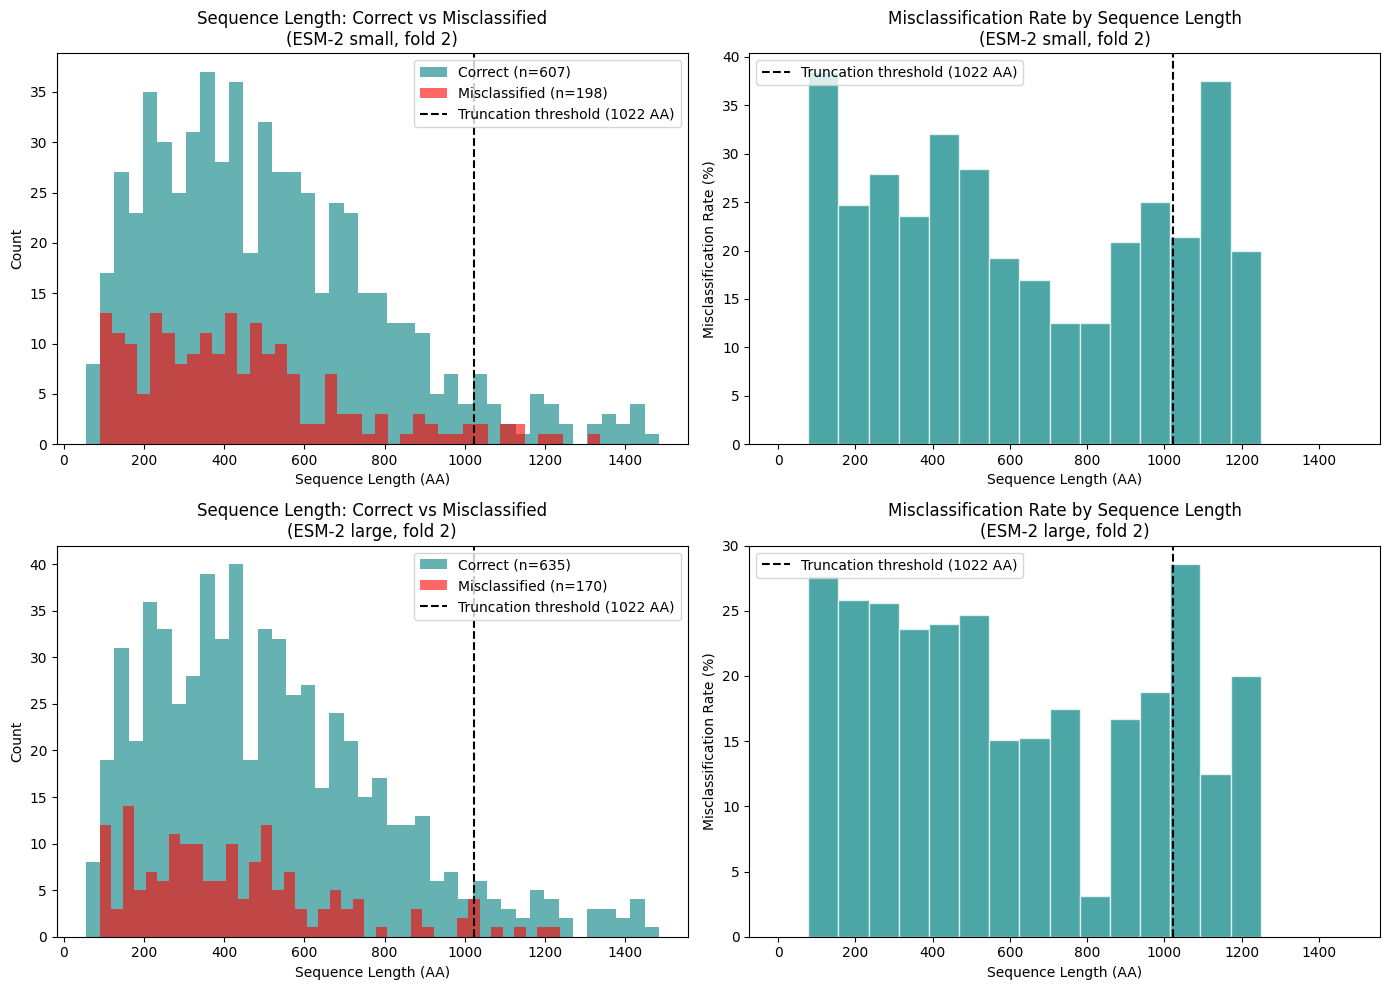

In [21]:
# Plot sequence length distributions: correct vs misclassified, per model size
fig, axes = plt.subplots(len(results), 2, figsize=(14, 5 * len(results)))
if len(results) == 1:
    axes = [axes]

for row, (size, ea) in enumerate(error_analysis.items()):
    correct = ea['correct']
    seq_lengths = ea['seq_lengths']

    # Left: overlapping histograms
    axes[row][0].hist(seq_lengths[correct], bins=40, alpha=0.6, color='teal',
                      label=f'Correct (n={correct.sum()})')
    axes[row][0].hist(seq_lengths[~correct], bins=40, alpha=0.6, color='red',
                      label=f'Misclassified (n={(~correct).sum()})')
    axes[row][0].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation threshold ({MAX_LEN-2} AA)')
    axes[row][0].set_title(f'Sequence Length: Correct vs Misclassified\n(ESM-2 {size}, fold {best_folds[size]+1})')
    axes[row][0].set_xlabel('Sequence Length (AA)')
    axes[row][0].set_ylabel('Count')
    axes[row][0].legend()

    # Right: misclassification rate by length bin
    bin_edges = np.linspace(0, seq_lengths.max(), 20)
    bin_indices = np.digitize(seq_lengths, bin_edges)
    bin_error_rates, bin_centres = [], []

    for b in range(1, len(bin_edges)):
        mask = bin_indices == b
        if mask.sum() >= 5:
            bin_error_rates.append((~correct[mask]).mean() * 100)
            bin_centres.append((bin_edges[b-1] + bin_edges[b]) / 2)

    axes[row][1].bar(bin_centres, bin_error_rates, width=bin_edges[1]-bin_edges[0],
                     color='teal', alpha=0.7, edgecolor='white')
    axes[row][1].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation threshold ({MAX_LEN-2} AA)')
    axes[row][1].set_title(f'Misclassification Rate by Sequence Length\n(ESM-2 {size}, fold {best_folds[size]+1})')
    axes[row][1].set_xlabel('Sequence Length (AA)')
    axes[row][1].set_ylabel('Misclassification Rate (%)')
    axes[row][1].legend()

plt.tight_layout()
plt.show()

Is the second best prediction correct?

In [22]:
# Top-2 prediction analysis per model size
for size, ea in error_analysis.items():
    val_logits = ea['val_logits']
    val_labels = ea['val_labels']
    correct = ea['correct']

    top2 = np.argsort(val_logits, axis=1)[:, ::-1][:, :2]
    top1_correct = correct
    top2_correct = top2[:, 1] == val_labels
    top1_or_top2 = top1_correct | top2_correct

    n_wrong = (~top1_correct).sum()
    print(f"\nTop-2 analysis — ESM-2 {size} (fold {best_folds[size]+1}):")
    print(f"  Top-1 accuracy:                  {top1_correct.mean()*100:.1f}%")
    print(f"  Top-2 accuracy (either correct): {top1_or_top2.mean()*100:.1f}%")
    print(f"\n  Of the {n_wrong} misclassified sequences:")
    print(f"    2nd guess correct: {top2_correct[~top1_correct].sum()} ({top2_correct[~top1_correct].mean()*100:.1f}%)")
    print(f"    2nd guess wrong:   {(~top2_correct[~top1_correct]).sum()} ({(~top2_correct[~top1_correct]).mean()*100:.1f}%)")
    print(f"    Random chance (1 in 7): 14.3%")


Top-2 analysis — ESM-2 small (fold 2):
  Top-1 accuracy:                  75.4%
  Top-2 accuracy (either correct): 88.3%

  Of the 198 misclassified sequences:
    2nd guess correct: 104 (52.5%)
    2nd guess wrong:   94 (47.5%)
    Random chance (1 in 7): 14.3%

Top-2 analysis — ESM-2 large (fold 2):
  Top-1 accuracy:                  78.9%
  Top-2 accuracy (either correct): 89.3%

  Of the 170 misclassified sequences:
    2nd guess correct: 84 (49.4%)
    2nd guess wrong:   86 (50.6%)
    Random chance (1 in 7): 14.3%


Cluster embeddings with PCA and colour by class

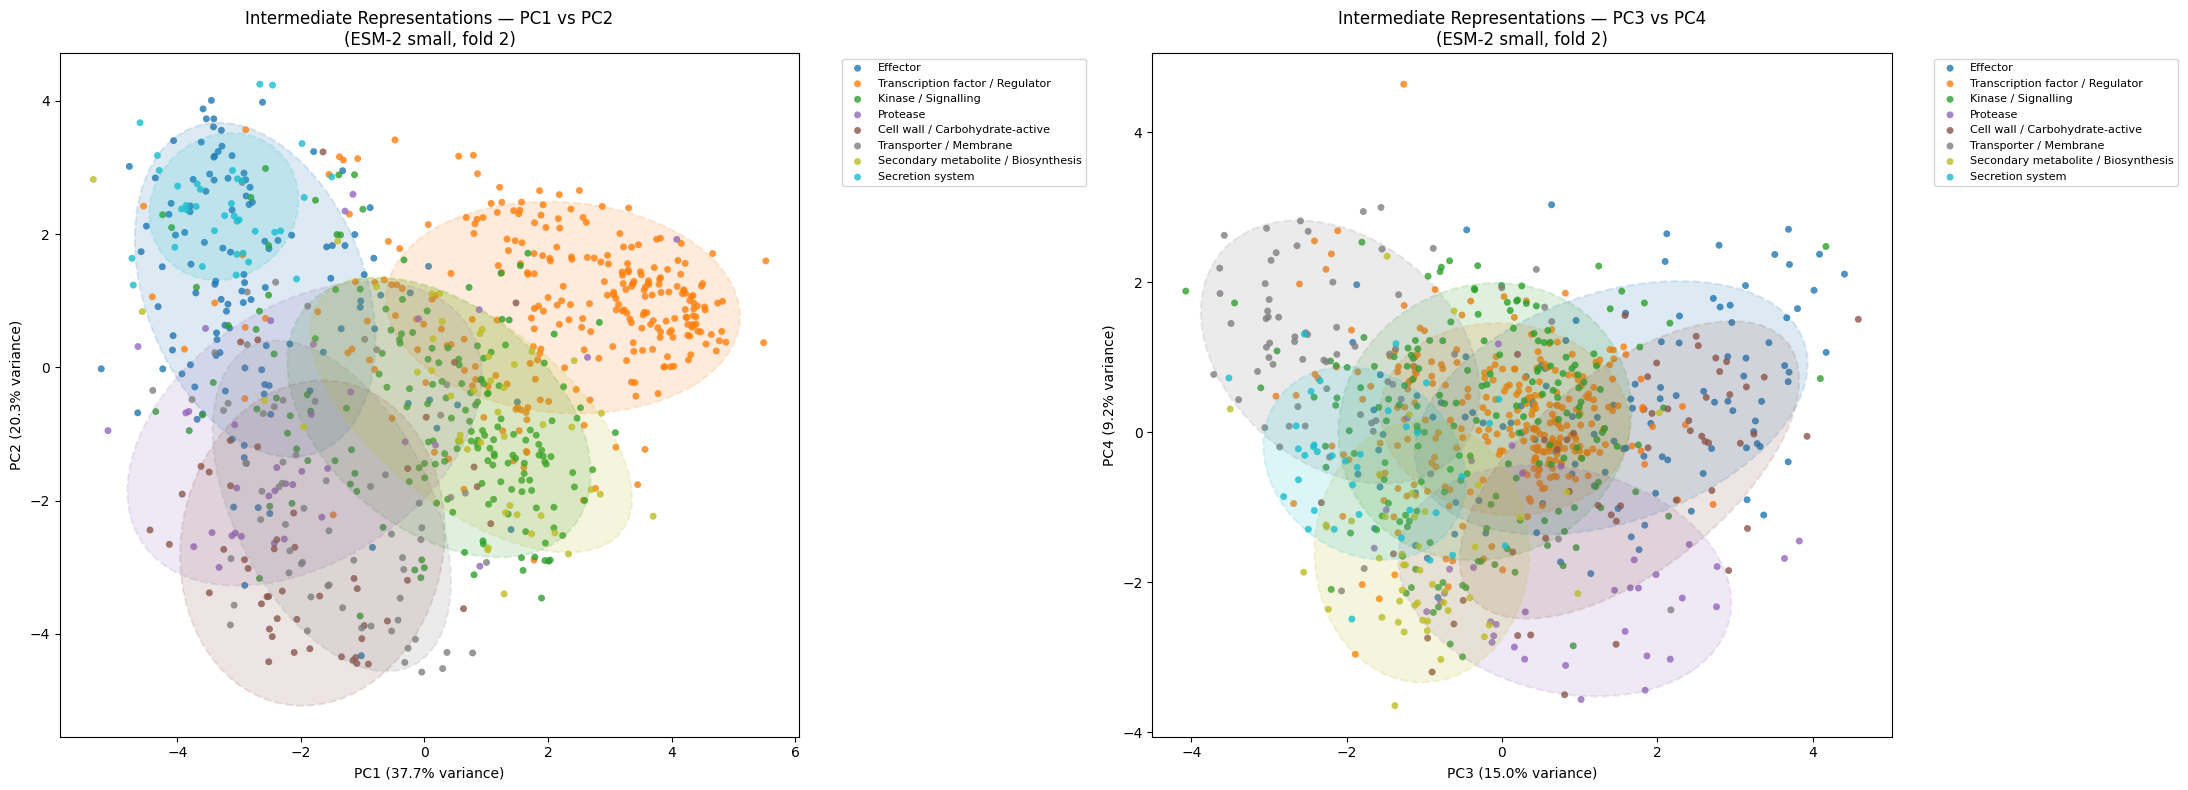


Variance explained — ESM-2 small:
  PC1: 37.7%
  PC2: 20.3%
  PC3: 15.0%
  PC4: 9.2%
  Total (PC1-4): 82.2%


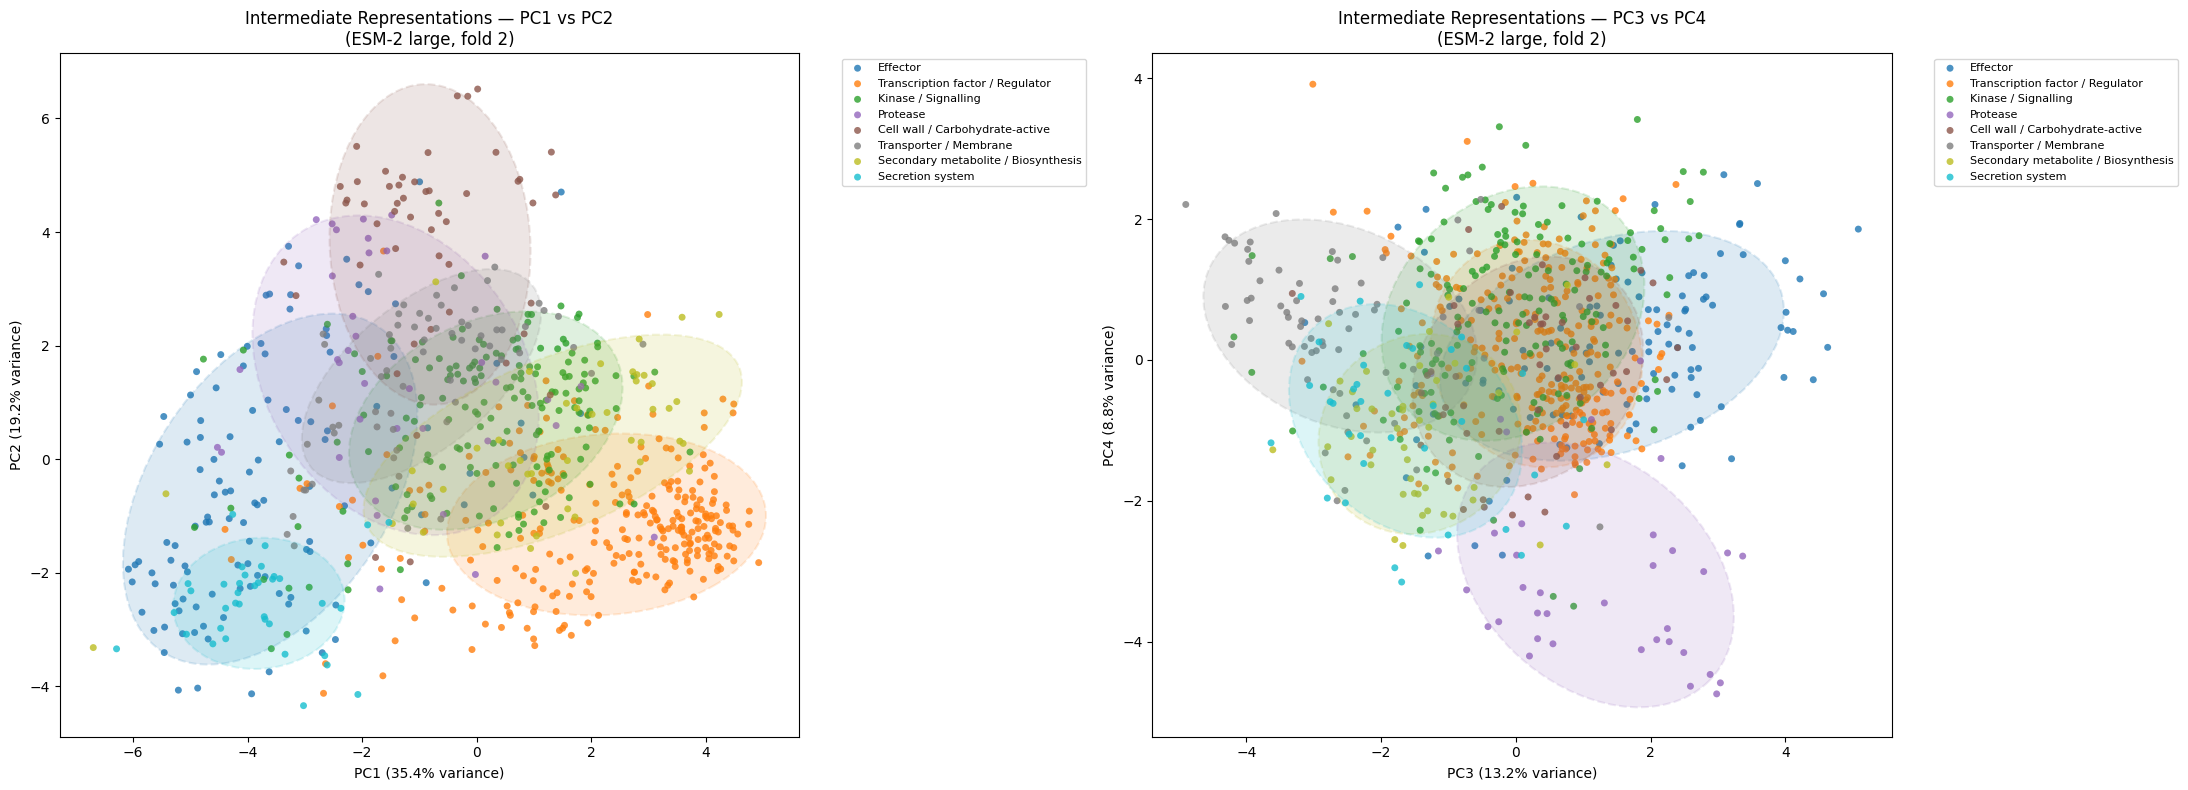


Variance explained — ESM-2 large:
  PC1: 35.4%
  PC2: 19.2%
  PC3: 13.2%
  PC4: 8.8%
  Total (PC1-4): 76.6%


In [23]:
# PCA of intermediate representations per model size
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

class VirulenceClassifierIntermediate(nn.Module):
    num_classes: int = 8
    hidden_dim: int = 640
    layer_1_dim: int = 256
    layer_2_dim: int = 128
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, esm_embeddings, attention_mask=None, training=False):
        if attention_mask is not None:
            mask = attention_mask[:, :, None]
            sum_embeddings = (esm_embeddings * mask).sum(axis=1)
            lengths = mask.sum(axis=1)
            pooled = sum_embeddings / lengths
        else:
            pooled = jnp.mean(esm_embeddings, axis=1)
        x = nn.Dense(self.layer_1_dim)(pooled)
        x = nn.relu(x)
        x = nn.Dense(self.layer_2_dim)(x)
        x = nn.relu(x)
        return x

def plot_confidence_ellipse(x, y, ax, color, n_std=1.5, alpha=0.15):
    if len(x) < 3:
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    rx, ry = np.sqrt(1 + pearson), np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=rx * 2, height=ry * 2,
                      facecolor=color, alpha=alpha, edgecolor=color,
                      linewidth=1.5, linestyle='--')
    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(np.mean(x), np.mean(y))
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

colors = plt.cm.tab10(np.linspace(0, 1, config['model']['num_classes']))

for size, ea in error_analysis.items():
    hidden_dim = config['model']['hidden_dims'][size]

    intermediate_model = VirulenceClassifierIntermediate(
        num_classes=config['model']['num_classes'],
        hidden_dim=hidden_dim,
        layer_1_dim=config['classification_head']['layer_1_dim'],
        layer_2_dim=config['classification_head']['layer_2_dim'],
        dropout_rate=config['model']['dropout_rate']
    )

    # Extract intermediate representations
    intermediates = np.concatenate([
        np.array(intermediate_model.apply(
            ea['best_params'],
            jnp.array(ea['fold_embs_val'][i:i+batch_size]),
            jnp.array(ea['fold_masks_val'][i:i+batch_size])
        ))
        for i in range(0, len(ea['val_labels']), batch_size)
    ], axis=0)

    pca = PCA(n_components=4)
    intermediates_pca = pca.fit_transform(intermediates)

    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (2, 3)]):
        for cls_idx in range(config['model']['num_classes']):
            mask = ea['val_labels'] == cls_idx
            color = colors[cls_idx]
            x = intermediates_pca[mask, pc_x]
            y = intermediates_pca[mask, pc_y]
            ax.scatter(x, y, c=[color], label=idx_to_class[cls_idx],
                       alpha=0.8, s=25, edgecolors='none')
            plot_confidence_ellipse(x, y, ax, color=color)

        ax.set_title(f'Intermediate Representations — PC{pc_x+1} vs PC{pc_y+1}\n(ESM-2 {size}, fold {best_folds[size]+1})')
        ax.set_xlabel(f'PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}% variance)')
        ax.set_ylabel(f'PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}% variance)')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

    print(f"\nVariance explained — ESM-2 {size}:")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {var*100:.1f}%")
    print(f"  Total (PC1-4): {pca.explained_variance_ratio_.sum()*100:.1f}%")

## 7 Memory and Performance Profiling

This section determines the maximum feasible batch size for both ESM-2 variants on the current Colab hardware and estimates full training duration. Since LoRA fine-tuning in notebook 03 requires gradients to flow through the encoder layers rather than just the classification head, these estimates represent a lower bound — LoRA training will be slower and more memory-intensive than the frozen baseline measured here.

In [24]:
import time

def get_gpu_memory():
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved  = torch.cuda.memory_reserved() / 1024**3
        total     = torch.cuda.get_device_properties(0).total_memory / 1024**3
        return allocated, reserved, total
    return None

allocated, reserved, total = get_gpu_memory()
print(f"GPU:                 {torch.cuda.get_device_name(0)}")
print(f"Total memory:        {total:.1f} GB")
print(f"Currently allocated: {allocated:.2f} GB")
print(f"Currently reserved:  {reserved:.2f} GB")
print(f"Available:           {total - reserved:.2f} GB")

GPU:                 NVIDIA A100-SXM4-40GB
Total memory:        39.5 GB
Currently allocated: 3.11 GB
Currently reserved:  4.90 GB
Available:           34.60 GB


In [25]:
# Profile forward pass at different batch sizes for both model sizes
test_batch_sizes = config['memory']['test_batch_sizes']
profiling_results = {}

for size, esm_model in esm_models.items():
    print(f"\nBatch size profiling — ESM-2 {size} (frozen forward pass):\n")
    print(f"{'Batch size':<15} {'Time (s)':<15} {'Peak GPU mem (GB)':<25} {'Status'}")
    print("-" * 70)

    feasible = []
    for bs in test_batch_sizes:
        try:
            dummy_seqs = ["A" * (config['memory']['max_token_length'] - 2)] * bs
            tokens = tokenizer(
                dummy_seqs,
                padding=True,
                truncation=True,
                max_length=config['memory']['max_token_length'],
                return_tensors="pt"
            )

            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            start = time.time()

            with torch.no_grad():
                inputs = {k: v.to("cuda") for k, v in tokens.items()}
                outputs = esm_model(**inputs)

            torch.cuda.synchronize()
            elapsed = time.time() - start
            peak_mem = torch.cuda.max_memory_allocated() / 1024**3

            feasible.append(bs)
            print(f"{bs:<15} {elapsed:<15.3f} {peak_mem:<25.2f} ✓ OK")

        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                print(f"{bs:<15} {'N/A':<15} {'N/A':<25} ✗ OOM")
                torch.cuda.empty_cache()
            else:
                raise e

    profiling_results[size] = {'feasible_batch_sizes': feasible}


Batch size profiling — ESM-2 small (frozen forward pass):

Batch size      Time (s)        Peak GPU mem (GB)         Status
----------------------------------------------------------------------
2               0.080           3.21                      ✓ OK
4               0.134           3.31                      ✓ OK
8               0.223           3.51                      ✓ OK
16              0.436           3.91                      ✓ OK

Batch size profiling — ESM-2 large (frozen forward pass):

Batch size      Time (s)        Peak GPU mem (GB)         Status
----------------------------------------------------------------------
2               0.188           3.34                      ✓ OK
4               0.362           3.51                      ✓ OK
8               0.717           3.91                      ✓ OK
16              1.419           4.71                      ✓ OK


In [26]:
# Profile full classification head training step at recommended batch size
for size, classifier in classifiers.items():
    recommended_bs = profiling_results[size]['feasible_batch_sizes'][-1]
    print(f"\nTraining step profiling — ESM-2 {size}, batch size {recommended_bs}:\n")

    embs_np, masks_np = embeddings_by_size[size]
    sample_embs   = jnp.array(embs_np[:recommended_bs])
    sample_masks  = jnp.array(masks_np[:recommended_bs])
    sample_labels = jnp.array(train_labels_np[:recommended_bs])

    # Use fold 0 params and a fresh optimiser for timing
    optimiser = optax.adam(learning_rate=config['training']['learning_rate'])
    timing_params = results[size]['best_params'][0]
    opt_state = optimiser.init(timing_params)
    train_step_fn = make_train_step(classifier, optimiser, class_weights_jax)

    # Warmup
    key = jax.random.PRNGKey(0)
    key, dropout_key = jax.random.split(key)
    _ = train_step_fn(timing_params, opt_state, sample_embs, sample_masks,
                      sample_labels, dropout_key)

    # Timed runs
    n_timed = 10
    times = []
    for i in range(n_timed):
        key, dropout_key = jax.random.split(key)
        start = time.time()
        _ = train_step_fn(timing_params, opt_state, sample_embs, sample_masks,
                          sample_labels, dropout_key)
        jax.effects_barrier()
        times.append(time.time() - start)

    mean_step_time = np.mean(times)
    steps_per_epoch = len(train_labels_np) // recommended_bs
    estimated_epoch_time = mean_step_time * steps_per_epoch

    profiling_results[size].update({
        'recommended_bs': recommended_bs,
        'mean_step_time_ms': mean_step_time * 1000,
        'steps_per_epoch': steps_per_epoch,
        'estimated_epoch_time_s': estimated_epoch_time
    })

    print(f"Mean step time:       {mean_step_time*1000:.1f} ms")
    print(f"Steps per epoch:      {steps_per_epoch}")
    print(f"Estimated epoch time: {estimated_epoch_time:.1f} s ({estimated_epoch_time/60:.1f} min)")
    print(f"Estimated 50 epochs:  {50 * estimated_epoch_time / 60:.1f} min")


Training step profiling — ESM-2 small, batch size 16:

Mean step time:       0.4 ms
Steps per epoch:      251
Estimated epoch time: 0.1 s (0.0 min)
Estimated 50 epochs:  0.1 min

Training step profiling — ESM-2 large, batch size 16:

Mean step time:       0.3 ms
Steps per epoch:      251
Estimated epoch time: 0.1 s (0.0 min)
Estimated 50 epochs:  0.1 min


In [27]:
# Summary
print("\nMemory and Performance Profiling Summary:")
print("=" * 60)
print(f"GPU: {torch.cuda.get_device_name(0)}\n")
print(f"{'Model':<10} {'Feasible batch sizes':<25} {'Recommended':<15} {'Step time (ms)':<18} {'Epoch time (min)'}")
print("-" * 85)
for size, pr in profiling_results.items():
    print(f"{size:<10} {str(pr['feasible_batch_sizes']):<25} {pr['recommended_bs']:<15} "
          f"{pr['mean_step_time_ms']:<18.1f} {pr['estimated_epoch_time_s']/60:.1f}")

print(f"\nNote: these timings reflect frozen embedding + classification head training only.")
print(f"LoRA fine-tuning will be slower as gradients flow through the ESM-2 encoder.")
print(f"\nRecommended batch sizes for notebook 03:")
for size, pr in profiling_results.items():
    print(f"  {size}: {pr['recommended_bs']}")


Memory and Performance Profiling Summary:
GPU: NVIDIA A100-SXM4-40GB

Model      Feasible batch sizes      Recommended     Step time (ms)     Epoch time (min)
-------------------------------------------------------------------------------------
small      [2, 4, 8, 16]             16              0.4                0.0
large      [2, 4, 8, 16]             16              0.3                0.0

Note: these timings reflect frozen embedding + classification head training only.
LoRA fine-tuning will be slower as gradients flow through the ESM-2 encoder.

Recommended batch sizes for notebook 03:
  small: 16
  large: 16


## Prototyping Takeaways

**Frozen baseline performance:** Both ESM-2 variants produce strong frozen baselines well above random chance (12.5%), confirming that pre-trained protein language model representations encode meaningful functional class signal without any fine-tuning. The large model (650M, macro F1: 0.733 ± 0.016) outperforms the small model (150M, macro F1: 0.698 ± 0.019) by ~0.035 macro F1 — a consistent but modest advantage suggesting the larger representations capture additional biochemical signal. The low standard deviation across folds for both models confirms stable training and that the result is not fold-dependent.

**Confusion patterns:** The dominant off-diagonal confusions are consistent with the biological ambiguities identified during data curation. Kinase / Signalling and Transcription factor / Regulator remain the primary confusion pair in both models, and Effectors are notably confused with Secretion system (10.6 mean misclassifications in the large model), consistent with the PHI:3753/PHI:6104 100% identity cross-class pair identified in the curation pipeline. Secondary metabolite / Biosynthesis and Secretion system are the weakest classes in both models, reflecting their smaller training sizes and annotation heterogeneity.

**Truncation:** Contrary to expectation, truncated sequences (>1,022 aa, 5.5% of validation data) are not disproportionately misclassified — accuracy on truncated sequences is higher than on full-length sequences for both models (small: 79.5% vs 75.2%; large: 86.4% vs 78.4%). Truncated sequences are predominantly large multi-domain proteins from well-represented classes where sufficient functional signal is retained within the 1,022 aa window. The random cropping strategy is therefore adequate for this dataset.

**Top-2 predictions:** Of the misclassified sequences, approximately half have the correct class as their second prediction (small: 52.5%; large: 49.4%), compared to a random chance baseline of 14.3%. This indicates the model is genuinely uncertain between two plausible classes rather than making arbitrary errors, consistent with the annotation ambiguity at class boundaries identified during curation. Top-2 accuracy of 88–89% for both models suggests LoRA fine-tuning — which sharpens decision boundaries rather than learning entirely new features — is likely to convert many near-misses into correct classifications.

**Intermediate representations:** PCA of the 128-dimensional classification head representations shows partial class separation, with Effectors forming the most compact and well-separated cluster in both models, consistent with their high within-class sequence identity (44.4%) and strong per-class F1. TF/Regulator and Kinase/Signalling show substantial overlap, confirming the confusion observed in the confusion matrices. The large model shows visibly better separation, particularly for Secretion system. PC1 and PC2 together capture ~55% of variance in both models, suggesting the dominant class signal is concentrated in the first two principal components.

**Memory and batch size:** Both ESM-2 variants comfortably fit batch size 16 on the A100-SXM4-40GB during frozen forward pass (peak memory 3.91 GB for small, 4.71 GB for large). These timings reflect classification head training on pre-extracted embeddings only and are not representative of LoRA fine-tuning, where gradients must flow through the encoder. A starting batch size of 4–8 is recommended for LoRA fine-tuning, to be confirmed by profiling in notebook 03.